# Onset of convection

In [ ]:
from functools import partial
import numpy as np
from lucifex.fdm import GridFunctionSeries, NPyConstantSeries
from lucifex.fem import refine_grid_function, grid_average
from lucifex.viz import (
    plot_colormap, plot_line, save_figure, plot_contours,
    plot_colormap_multifigure, plot_line_multifigure,
)
from lucifex.utils.array_utils import as_index
from lucifex.io import create_dir_path, find_dir_paths
from lucifex.utils.py_utils import FrozenDict
from lucifex.sim import GridSimulationFromNPZ
from crocodil.dns.system_a import SYSTEM_A_REFERENCE
from ipynb_utils import as_int_if_poss, when_geq_first

# searching for any simulations in the root directory
PARAMS_NUMERICAL = FrozenDict(
    c_stabilization=None,
    c_limits=True,
)
DIR_ROOT = create_dir_path(
    PARAMS_NUMERICAL, 
    dir_root='./',
    dir_prefix='data', 
    dir_params=PARAMS_NUMERICAL.keys(), 
)
DIR_FIGS = f'{DIR_ROOT}/figures'

T_STOP = 120.0
sim_dir_paths = find_dir_paths(
    DIR_ROOT, 
    include=f't_stop={T_STOP}_*',
    contains=('CHECKPOINT.h5', 'c.npz'),
)

# selecting a batch of simulations
PARAMS_BATCH = SYSTEM_A_REFERENCE.remove('Ra', 'Da')
simulations_batch = GridSimulationFromNPZ.dict_from_dir_paths(
    ('Ra', 'Da'), 
    sim_dir_paths,
    ('c', 'psi'),
    ('uRMS', ),
    PARAMS_BATCH,
    lazy=True,
    sorting=lambda d: dict(sorted(d.items(), reverse=False)),
)

# utilities for plotting
epsilon, zeta0, sr, cr, aspect = PARAMS_BATCH['epsilon', 'zeta0', 'sr', 'cr', 'aspect']
Ly = 1.0
Lx = aspect * Ly
save_figure = partial(
    save_figure, 
    dir_path=DIR_FIGS, 
    prefix='onset', 
    pickle=True,
    file_ext=('svg', 'png'),
)

In [7]:
print('Before parameter selection')
for i in sim_dir_paths: print(i)
print('After parameter selection')
for i in simulations_batch.values(): print(i.dir_path)

Before parameter selection
./data__c_stabilization=None|c_limits=True/t_stop=120.0__Ra=100.0|Da=1.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__8cdc0d7deee27009/
./data__c_stabilization=None|c_limits=True/t_stop=120.0__Ra=100.0|Da=10.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__f1e8b107b29abbbb/
./data__c_stabilization=None|c_limits=True/t_stop=120.0__Ra=100.0|Da=100.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__5e822ff46ee05fa4/
./data__c_stabilization=None|c_limits=True/t_stop=120.0__Ra=100.0|Da=1000.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__3823d90f6e03a6fd/
./data__c_stabilization=None|c_limits=True/t_stop=120.0__Ra=500.0|Da=1.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__795c9d7125905bce/
./data__c_stabilization=None|c_limits=True/t_stop=120.0__Ra=500.0|Da=10.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__c4deca4f8fe27111/
./data__c_stabilization=None|c_limits=True

In [8]:
# selecting a subset within the batch of simulations
Ra_targets = (500.0, 1000.0, )
Da_targets = (100.0, )
include = lambda prm, trgs: prm in trgs if trgs else True
simulations = {
    (Ra, Da): v for (Ra, Da), v in simulations_batch.items()
    if include(Ra, Ra_targets) and include(Da, Da_targets)
}

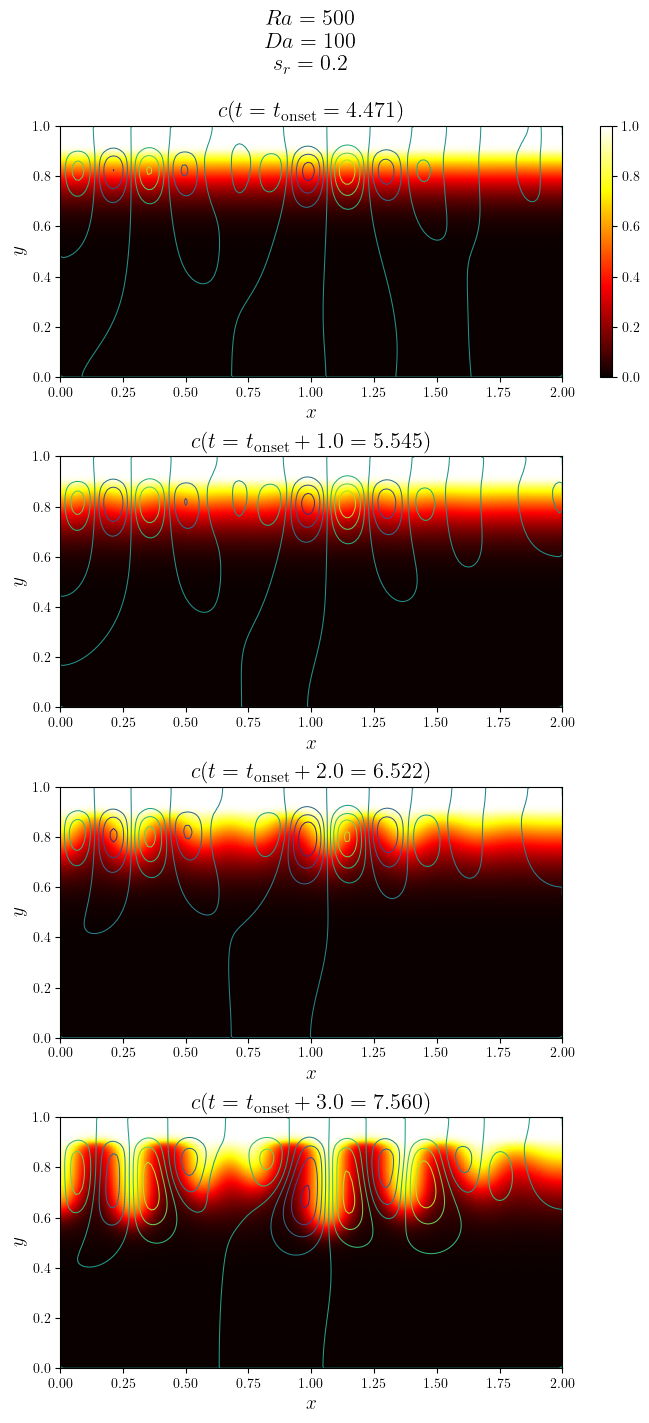

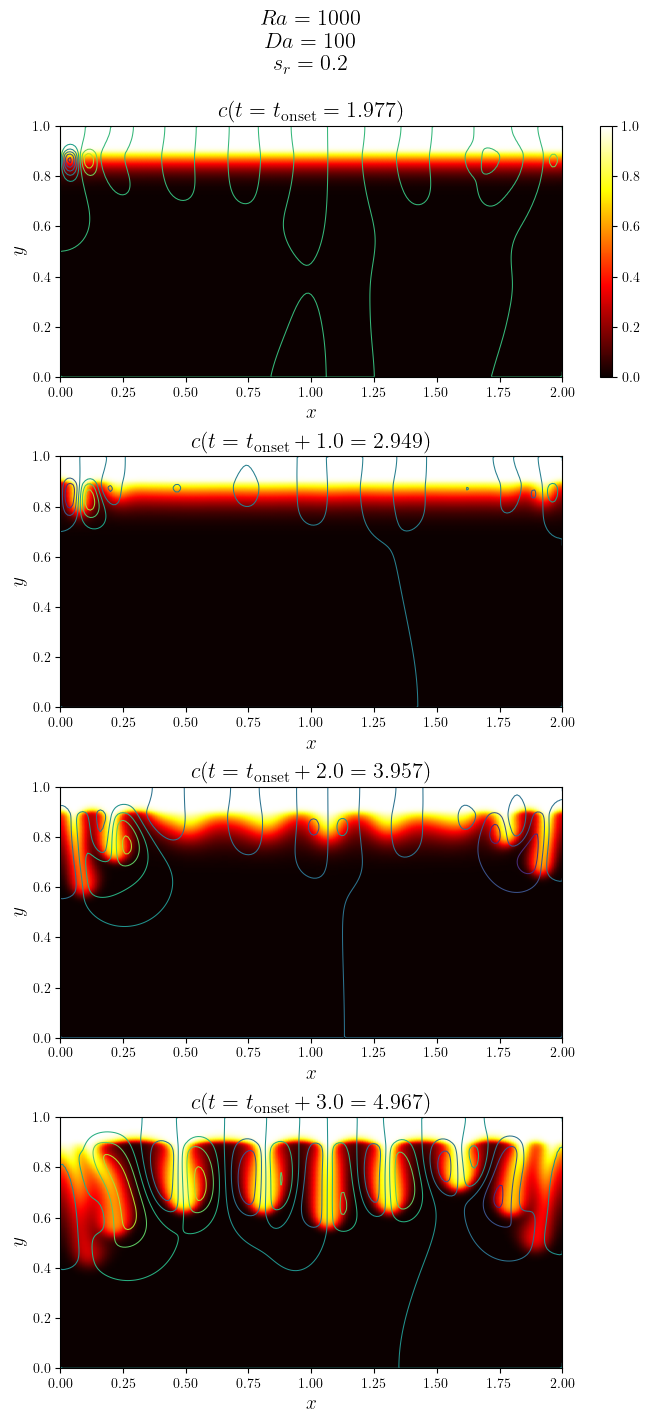

In [24]:
CONTOURS = True
uRMS_onset = 1e-3
tDelta = 1.0
nDelta = 4

for (Ra, Da), sim in simulations.items():
    c, s, uRMS = sim['c', 's', 'uRMS']
    c_funcs, c_titles, psi_funcs = [], [], []
    tOnset = when_geq_first(uRMS.value_series, uRMS.time_series, uRMS_onset)
    for i in range(nDelta):
        t_trg = tOnset + i * tDelta
        if i == 0:
            supttl = '\n'.join((f'$Ra={as_int_if_poss(Ra)}$', f'$Da={as_int_if_poss(Da)}$', f'$s_r={as_int_if_poss(sr)}$'))
            supttl = f'{supttl}\n\n'
            ttl = 't_{{\mathrm{{onset}}}}'
        else:
            supttl = ''
            ttl = f't_{{\mathrm{{onset}}}} + {i * tDelta:.1f}'
        c_time_index = as_index(c.time_series, t_trg)
        c_funcs.append(c.series[c_time_index])
        c_titles.append(f'{supttl}$c(t={ttl}={c.time_series[c_time_index]:.3f})$')
        if CONTOURS:
            psi = sim['psi']
            assert np.isclose(c.time_series[c_time_index], psi.time_series[c_time_index])
            psi_funcs.append(psi.series[c_time_index])

    fig, axs, _  = plot_colormap_multifigure(n_cols=1, cbars=(0, 1))(
        c_funcs, title=c_titles,
    )
    if CONTOURS:
        [plot_contours(fig, ax, psi_func, cmap='viridis') for ax, psi_func in zip(axs, psi_funcs)]
    # if DIR_FIGS: save_figure(f'c(x,y,t={c_t_trg})')(fig, file_ext=('pdf', 'png'))
